# Predicting Financial Time Series Data with Machine Learning

This is a sample that predicts future prices from past price movements.
Here we implement it with EUR/USD rate as an example, but you can convert it to stock price by editing the symbol.


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X
Date,,,,,,
2023-08-18,1.087465,1.087465,1.089562,1.084646,1.087465,0
2023-08-21,1.087559,1.087559,1.091358,1.087063,1.087559,0
2023-08-22,1.089835,1.089835,1.093200,1.083400,1.089835,0
2023-08-23,1.084669,1.084669,1.087051,1.080299,1.084669,0
2023-08-24,1.086579,1.086579,1.087690,1.081549,1.086579,0


Price      Adj Close     Close      High       Low      Open   Volume
Ticker      EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X EURUSD=X
Date                                                                 
2023-08-18  1.087465  1.087465  1.089562  1.084646  1.087465        0
2023-08-21  1.087559  1.087559  1.091358  1.087063  1.087559        0
2023-08-22  1.089835  1.089835  1.093200  1.083400  1.089835        0
2023-08-23  1.084669  1.084669  1.087051  1.080299  1.084669        0
2023-08-24  1.086579  1.086579  1.087690  1.081549  1.086579        0


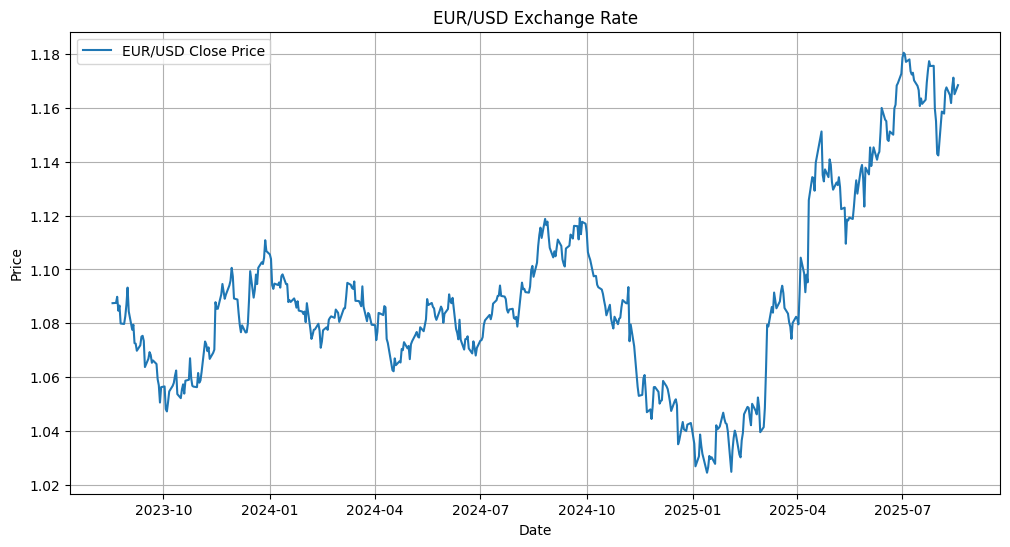

In [46]:
import numpy as np
import pandas as pd
import yfinance as yf  # Import yfinance for data retrieval
import matplotlib.pyplot as plt
import joblib
from IPython.display import display

%matplotlib inline

# Define the ticker symbol for EUR/USD
ticker_symbol = 'EURUSD=X'
ticker_interval = '1d' # change this to adjust granularity and train a separate model on that granularity. Options: 15m, 30m, 1h, 1d.

def fetch_data():
    try:
        if ticker_interval == '1d':
            ticker_period = '2y'
            data = yf.download(ticker_symbol, period=ticker_period, progress=False, auto_adjust=False)
        else:
            ticker_period = '1mo'
            data = yf.download(ticker_symbol, period=ticker_period, interval=ticker_interval, auto_adjust=False)
        return data
    except Exception as e:
        print(f"An error occurred: {str(e)}")
        return None

try:
    # fetching last 60 days of data with 15min granularity because-
    # i thought it'll be more optimal to train the model on.
    data = fetch_data()

    # Display the first few rows of the data
    display(data.head())
    # DEBUG
    print(data.head())

    # You can now work with the 'data' DataFrame for your analysis or plotting.
    
    # Example: Plotting the Close prices
    plt.figure(figsize=(12, 6))
    plt.plot(data['Close'], label='EUR/USD Close Price')
    plt.title('EUR/USD Exchange Rate')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.show()
    
except Exception as e:
    print(f"An error occurred: {str(e)}")


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X
Date,,,,,,
2023-08-18,0.91957,0.91957,0.917800,0.92196,0.91957,0
2023-08-21,0.91949,0.91949,0.916290,0.91991,0.91949,0
2023-08-22,0.91757,0.91757,0.914746,0.92302,0.91757,0
2023-08-23,0.92194,0.92194,0.919920,0.92567,0.92194,0
2023-08-24,0.92032,0.92032,0.919380,0.92460,0.92032,0


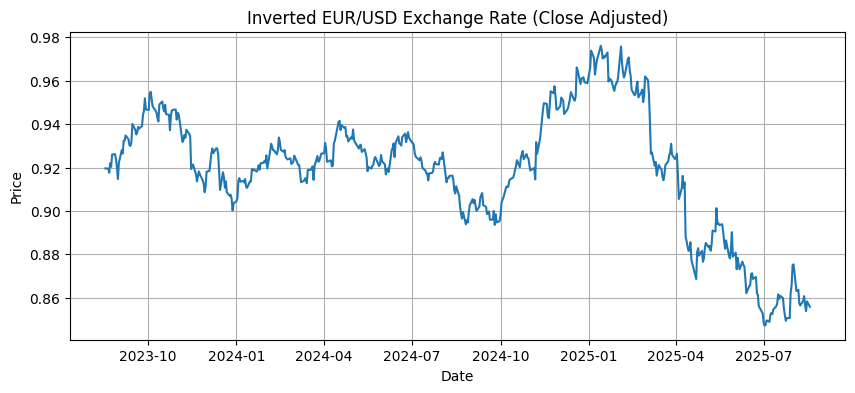

In [47]:
# Put data into Pandas Dataframe
df = pd.DataFrame(data)
df[['Open','High','Low','Close','Adj Close']] = df[['Open','High','Low','Close','Adj Close']].apply(lambda x: 1.0/x)
# Display the first few rows of the DataFrame
display(df.head())

# Plot the 'Close Adjusted' column
plt.figure(figsize=(10, 4))
plt.plot(df['Adj Close'], label='Inverted Close Adjusted Price')
plt.title('Inverted EUR/USD Exchange Rate (Close Adjusted)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

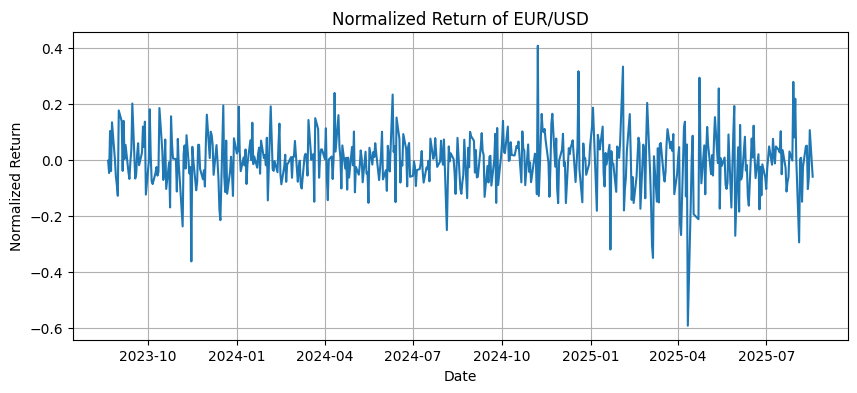

In [48]:
# Normalize aclose value and plot 'return' column
df['Return'] = df['Adj Close'] - df['Adj Close'].shift(1)
return_range = df['Return'].max() - df['Return'].min()
df['Return'] = df['Return'] / return_range

plt.figure(figsize=(10, 4))
plt.plot(df['Return'], label='Return')
plt.title('Normalized Return of EUR/USD')
plt.xlabel('Date')
plt.ylabel('Normalized Return')
plt.grid(True)
plt.show()


In [49]:
# Make label, 1 as rising price, 0 as falling price
df['Label'] = df['Return'].shift(-1)
df['Label'] = df['Label'].apply(lambda x: 1 if x > 0.0 else 0)

# Display the tail of the DataFrame with labels
df.tail()

Price,Adj Close,Close,High,Low,Open,Volume,Return,Label
Ticker,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X,,
Date,,,,,,,,
2025-08-12,0.86070,0.86070,0.85510,0.86212,0.86070,0,0.051956,0
2025-08-13,0.85638,0.85638,0.85247,0.85676,0.85638,0,-0.102955,0
2025-08-14,0.85376,0.85376,0.85356,0.85922,0.85376,0,-0.062441,1
2025-08-15,0.85827,0.85827,0.85359,0.85853,0.85827,0,0.107482,0
2025-08-18,0.85580,0.85580,0.85290,0.85650,0.85440,0,-0.058865,0


In [50]:

# Reset the index of the DataFrame
df.reset_index(drop=True, inplace=True)

n_features = 13  # number of features

train_x = np.array([]).reshape([-1, n_features])
train_y = np.array([]).reshape([-1, 1])

# Check if 'Label' is in the columns of your DataFrame
if 'Label' not in df.columns:
    print("The 'Label' column does not exist in your DataFrame.")
else:
    for index, row in df.iterrows():
        i = df.index.get_loc(index)
        if i < n_features:
            continue

        _x = np.array(df[i - n_features + 1:i + 1]['Return']).T.reshape([1, -1])
        print(df)
        _y = df.loc[i, 'Label']  # Use 'loc' method to access DataFrame values

        train_x = np.vstack((train_x, _x))
        train_y = np.vstack((train_y, _y))

    # Reshape train_y to 1D array
    train_y = train_y.reshape(-1)

    print(train_x.shape)
    print(train_y.shape)
    print('%% of Class 0: %f' % (np.count_nonzero(train_y == 0) / float(len(train_y))))
    print('%% of Class 1: %f' % (np.count_nonzero(train_y == 1) / float(len(train_y))))


Price  Adj Close    Close      High      Low     Open   Volume    Return Label
Ticker  EURUSD=X EURUSD=X  EURUSD=X EURUSD=X EURUSD=X EURUSD=X                
0        0.91957  0.91957  0.917800  0.92196  0.91957        0       NaN     0
1        0.91949  0.91949  0.916290  0.91991  0.91949        0 -0.001907     0
2        0.91757  0.91757  0.914746  0.92302  0.91757        0 -0.045758     1
3        0.92194  0.92194  0.919920  0.92567  0.92194        0  0.104149     0
4        0.92032  0.92032  0.919380  0.92460  0.92032        0 -0.038610     1
..           ...      ...       ...      ...      ...      ...       ...   ...
514      0.86070  0.86070  0.855100  0.86212  0.86070        0  0.051956     0
515      0.85638  0.85638  0.852470  0.85676  0.85638        0 -0.102955     0
516      0.85376  0.85376  0.853560  0.85922  0.85376        0 -0.062441     1
517      0.85827  0.85827  0.853590  0.85853  0.85827        0  0.107482     0
518      0.85580  0.85580  0.852900  0.85650  0.8544

In [58]:
# Define Model and fit
# Here we use 95% of data for training, and last 5% for testing

from sklearn.ensemble import GradientBoostingClassifier
clf = GradientBoostingClassifier(random_state=0, learning_rate=0.0018, n_estimators=10000)

train_len = int(len(train_x)*0.95)
clf.fit(train_x[:train_len], train_y[:train_len])

accuracy = clf.score(train_x[train_len:], train_y[train_len:])
print('Testing Accuracy: %f' % accuracy)

Testing Accuracy: 0.653846


,Return,Label,Pred,Won,Pnl,Equity
20,0.00218,1.0,0.0,False,-0.218007,-1.996990
21,-0.00432,0.0,0.0,True,0.432001,-1.564989
22,-0.00262,0.0,0.0,True,0.262000,-1.302989
23,0.00451,1.0,1.0,True,0.450995,-0.851994
24,-0.00247,0.0,0.0,True,0.246998,-0.604995


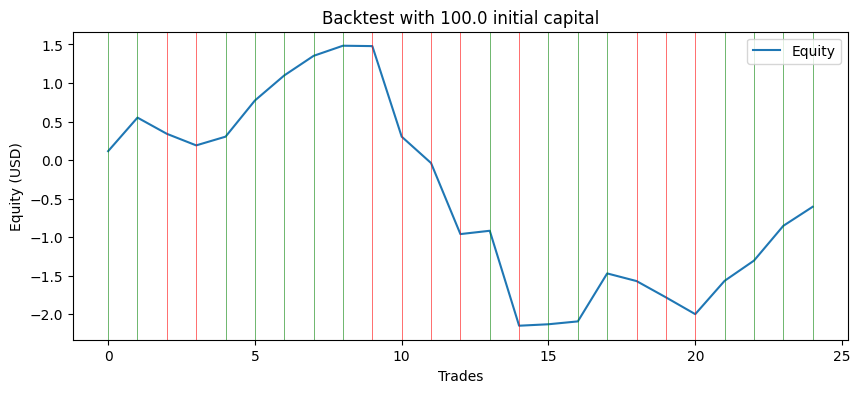

In [56]:
# Predict test data

pred = clf.predict(train_x[train_len:])


# Calculate equity..

contracts  = 100.0
commission = 0.0


df_trade = pd.DataFrame(train_x[train_len:,-1], columns=['Return'])
df_trade['Label']  = train_y[train_len:]
df_trade['Pred']   = pred
df_trade['Won']    = df_trade['Label'] == df_trade['Pred']
df_trade['Return'] = df_trade['Return'].shift(-1) * return_range
df_trade.drop(df_trade.index[len(df_trade)-1], inplace=True)

def calc_profit(row):
    if row['Won']:
        return abs(row['Return'])*contracts - commission
    else:
        return -abs(row['Return'])*contracts - commission

df_trade['Pnl'] = df_trade.apply(lambda row: calc_profit(row), axis=1)
df_trade['Equity'] = df_trade['Pnl'].cumsum()

display(df_trade.tail())
df_trade.plot(y='Equity', figsize=(10,4), title=f'Backtest with {contracts} initial capital')
plt.xlabel('Trades')
plt.ylabel('Equity (USD)')
for r in df_trade.iterrows():
    if r[1]['Won']:
        plt.axvline(x=r[0], linewidth=0.5, alpha=0.8, color='g')
    else:
        plt.axvline(x=r[0], linewidth=0.5, alpha=0.8, color='r')

Net Profit            : $-0.60
Number Winning Trades : 15
Number Losing Trades  : 10
Percent Profitable    : 60.00%
Avg Win Trade         : $0.264
Avg Los Trade         : $-0.456
Largest Win Trade     : $0.622
Largest Los Trade     : $-1.231
Profit Factor         : 0.87


<Axes: >

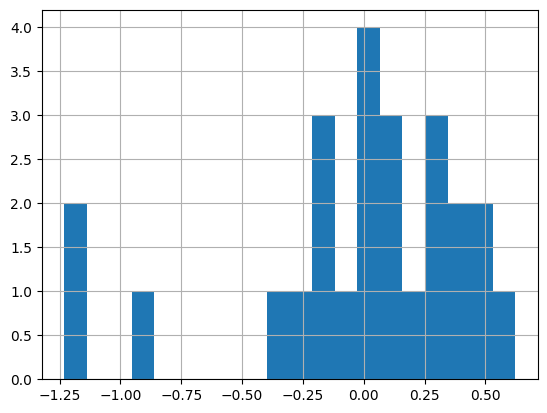

In [57]:
# Calculate summary of trades

n_win_trades = float(df_trade[df_trade['Pnl']>0.0]['Pnl'].count())
n_los_trades = float(df_trade[df_trade['Pnl']<0.0]['Pnl'].count())
print("Net Profit            : $%.2f" % float(df_trade.tail(1)['Equity'].iloc[0]))
print("Number Winning Trades : %d" % n_win_trades)
print("Number Losing Trades  : %d" % n_los_trades)
print("Percent Profitable    : %.2f%%" % (100*n_win_trades/(n_win_trades + n_los_trades)))
print("Avg Win Trade         : $%.3f" % df_trade[df_trade['Pnl']>0.0]['Pnl'].mean())
print("Avg Los Trade         : $%.3f" % df_trade[df_trade['Pnl']<0.0]['Pnl'].mean())
print("Largest Win Trade     : $%.3f" % df_trade[df_trade['Pnl']>0.0]['Pnl'].max())
print("Largest Los Trade     : $%.3f" % df_trade[df_trade['Pnl']<0.0]['Pnl'].min())
print("Profit Factor         : %.2f" % abs(df_trade[df_trade['Pnl']>0.0]['Pnl'].sum()/df_trade[df_trade['Pnl']<0.0]['Pnl'].sum()))

df_trade['Pnl'].hist(bins=20)

In [54]:
import os

# Get the parent directory of the notebook's directory
parent_directory = os.path.dirname(os.getcwd())

# Define the directory path for saving the model within the "models" directory
model_directory = os.path.join(parent_directory, "models")

# Create the "models" directory if it doesn't exist
if not os.path.exists(model_directory):
    os.makedirs(model_directory)

# Define the file path for saving the model
model_filename = os.path.join(model_directory, f"{ticker_interval}.h5")

# Save the trained model to a file
joblib.dump(clf, model_filename)

# Print a message to confirm the model has been saved
print("Trained model saved to", model_filename)

Trained model saved to c:\Users\infin\Desktop\some-trader-idk\models\1d.h5
